In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/Clean_Dataset.csv")

In [ ]:
print(df.head(10))

In [10]:
print("Nombre de lignes et colonnes :", df.shape)

Nombre de lignes et colonnes : (300153, 12)


In [ ]:
df.info()

In [ ]:
print(df.isnull().sum())

In [ ]:
statistics = df.describe()

statistics

In [ ]:
print(df.columns)

In [ ]:
print(df.dtypes)

In [24]:
variable_discrete = [
    'airline',
    'flight',
    'source_city',
    'destination_city',
    'departure_time',
    'stops',
    'arrival_time',
    'class'
]


In [ ]:
for col in variable_discrete:
    print(f"Value counts for {col}:")
    print(df[col].value_counts())
    print("\n")

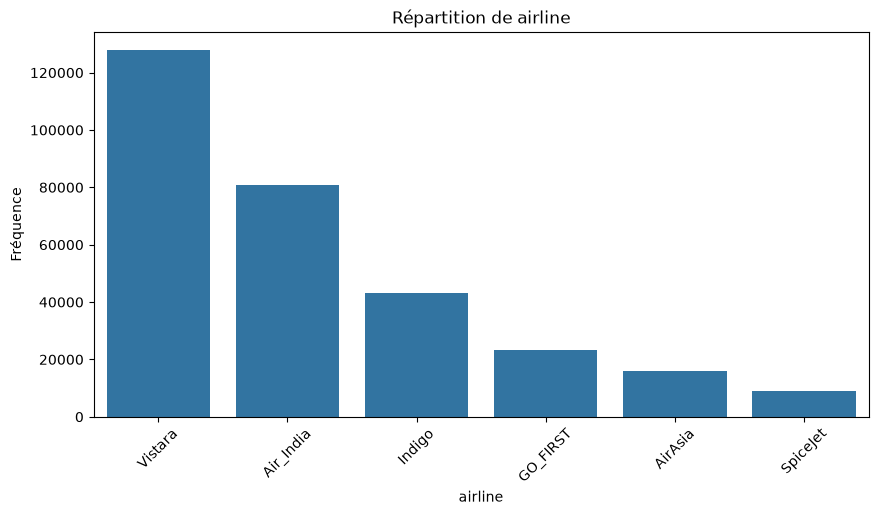

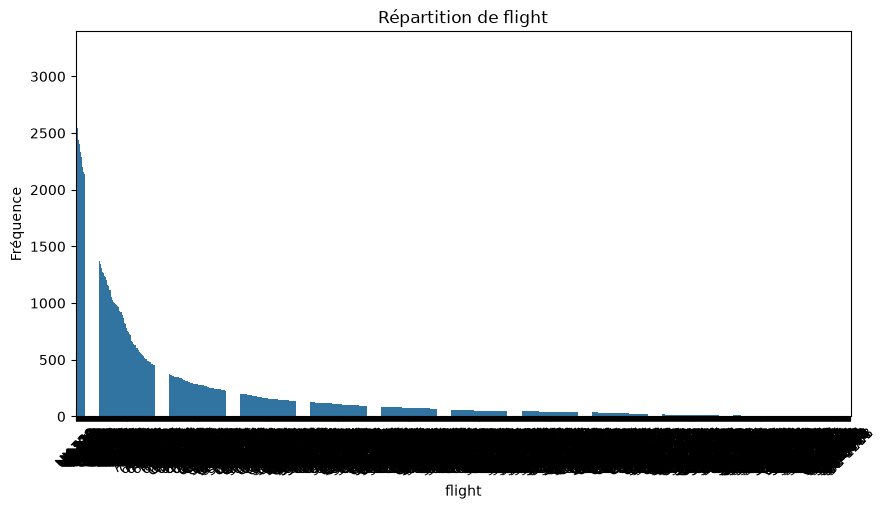

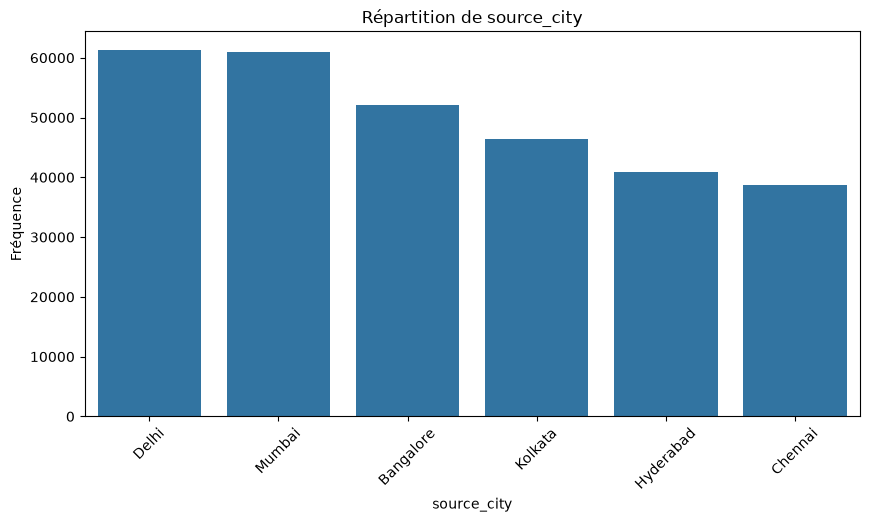

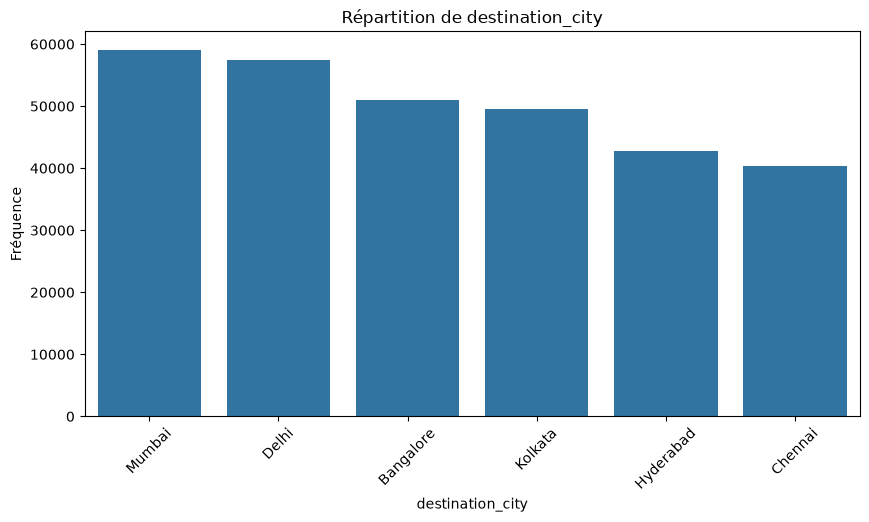

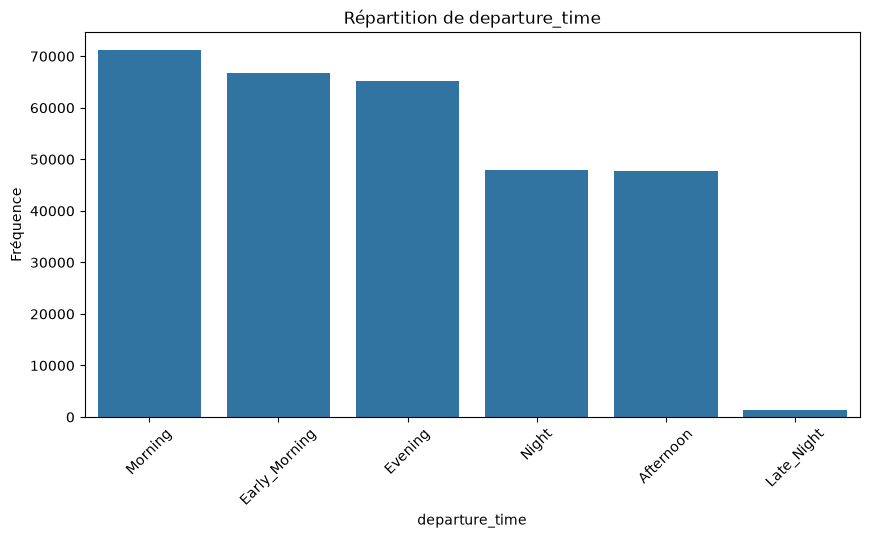

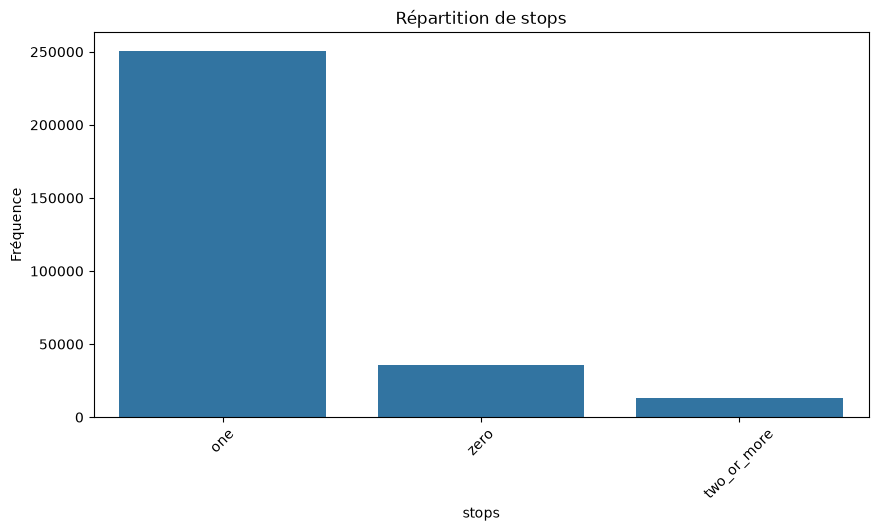

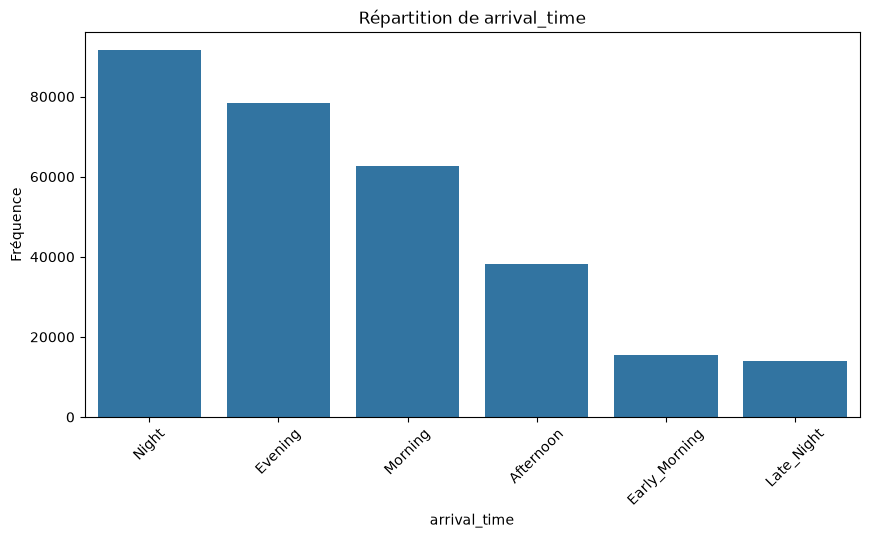

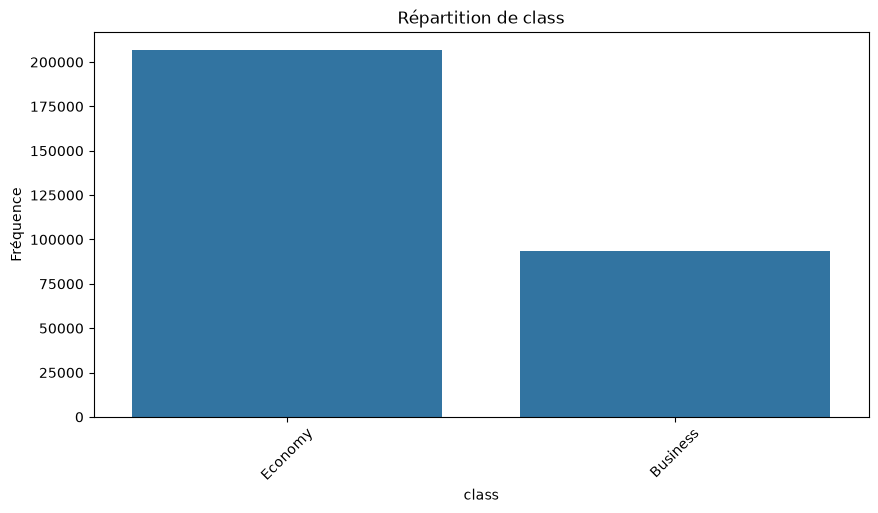

In [26]:
#Bar plots for discrete variables
import matplotlib.pyplot as plt
import seaborn as sns

for col in variable_discrete:
    plt.figure(figsize=(10, 5))
    
    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )
    
    plt.title(f"Répartition de {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.xticks(rotation=45)
    plt.show()

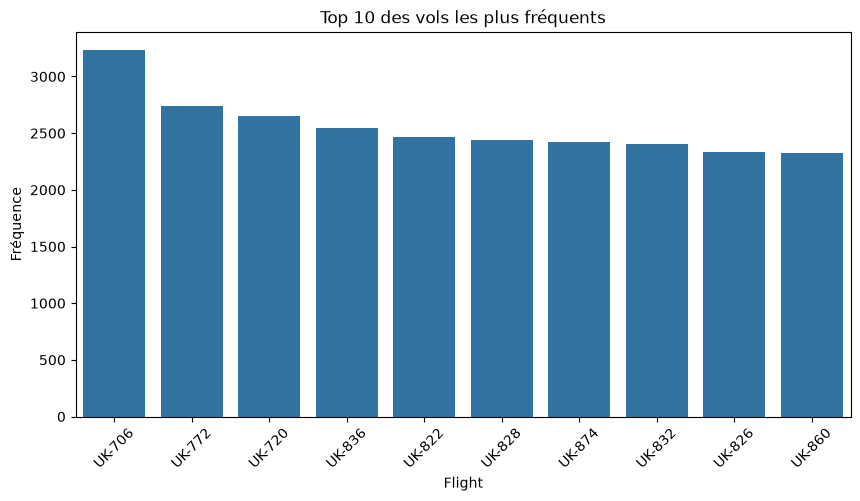

In [27]:
#flight représentation graphique des 10 vols les plus fréquents
top_flights = df['flight'].value_counts().head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=top_flights.index,
    y=top_flights.values
)

plt.title("Top 10 des vols les plus fréquents")
plt.xlabel("Flight")
plt.ylabel("Fréquence")
plt.xticks(rotation=45)

plt.show()

In [4]:
variable_continue = [
    'duration',
    'days_left',
    'price'
]

In [ ]:
df[variable_continue].describe()

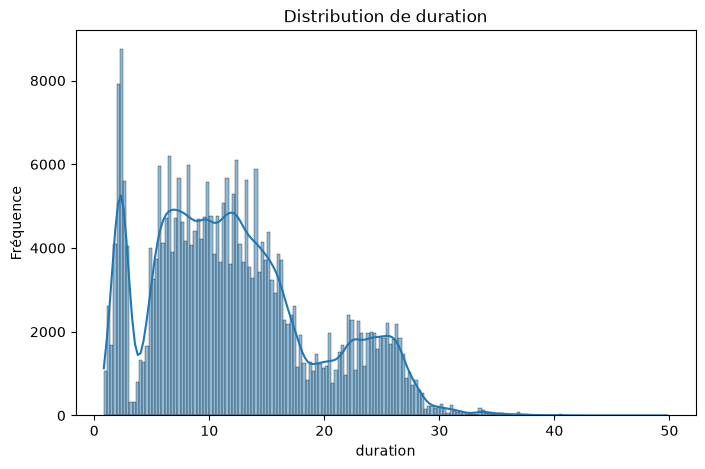

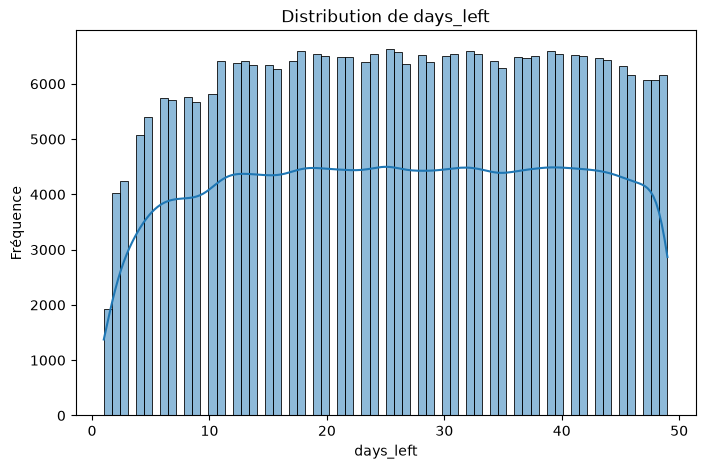

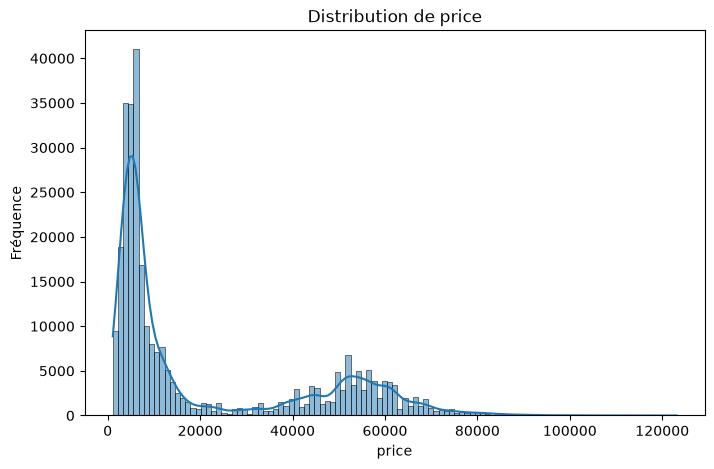

In [28]:
#histogrammes pour les variables continues
for col in variable_continue:
    plt.figure(figsize=(8, 5))
    
    sns.histplot(
        data=df,
        x=col,
        kde=True     #Kernel Density Estimate
    )
    
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.show()

In [ ]:
#boxplots pour les variables continues
for col in variable_continue:
    plt.figure(figsize=(8, 3))
    
    sns.boxplot(
        data=df,
        x=col
    )
    
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()

In [ ]:
pd.crosstab(df['source_city'],df['destination_city'])

In [ ]:
#scatter plot pour visualiser la relation entre deux variable continues
sns.scatterplot(data=df, x='duration', y='price')

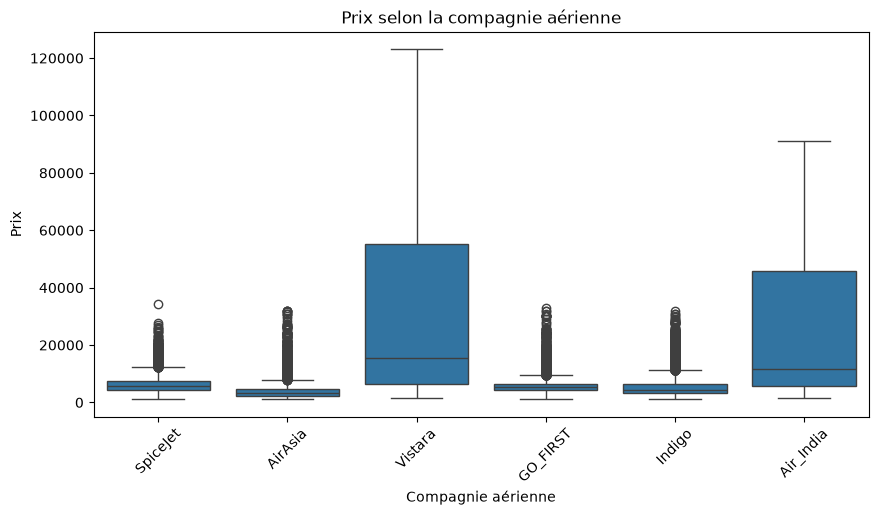

In [18]:
#airline vs price
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x='airline',
    y='price'
)

plt.title("Prix selon la compagnie aérienne")
plt.xlabel("Compagnie aérienne")
plt.ylabel("Prix")
plt.xticks(rotation=45)
plt.show()

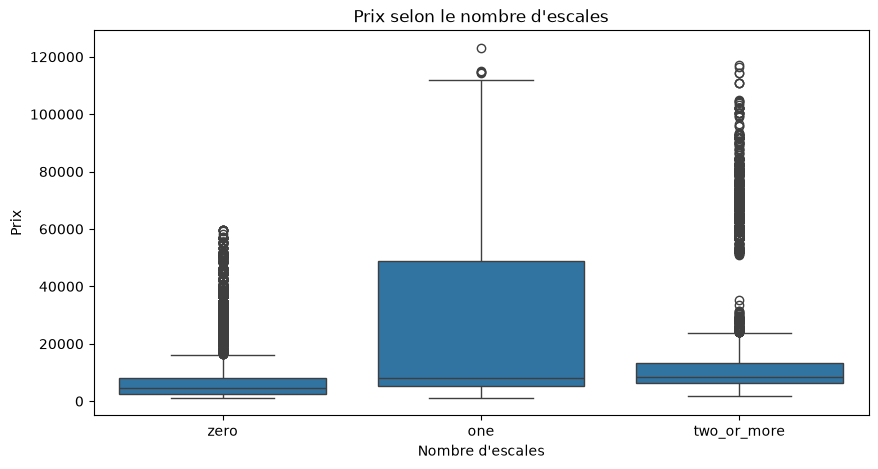

In [16]:
#stops vs price
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x='stops',
    y='price'
)
plt.title("Prix selon le nombre d'escales")
plt.xlabel("Nombre d'escales")
plt.ylabel("Prix")
plt.show()

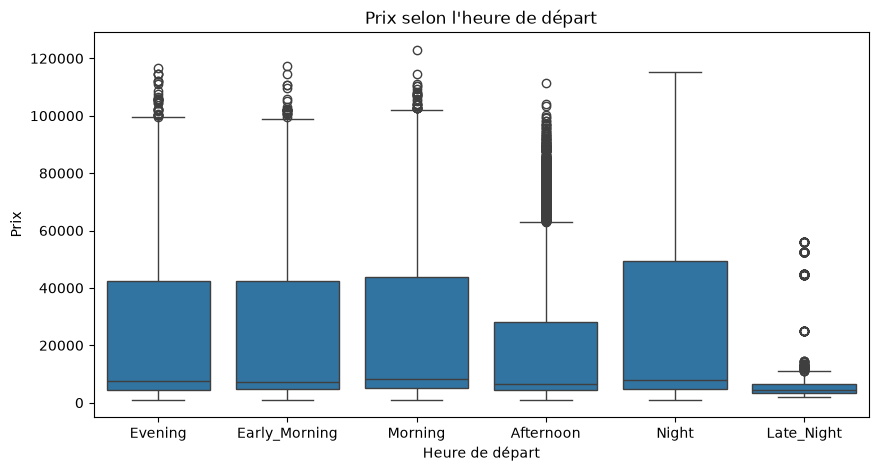

In [17]:
#departure_time vs price
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x='departure_time',
    y='price'
)
plt.title("Prix selon l'heure de départ")   
plt.xlabel("Heure de départ")
plt.ylabel("Prix")
plt.show()

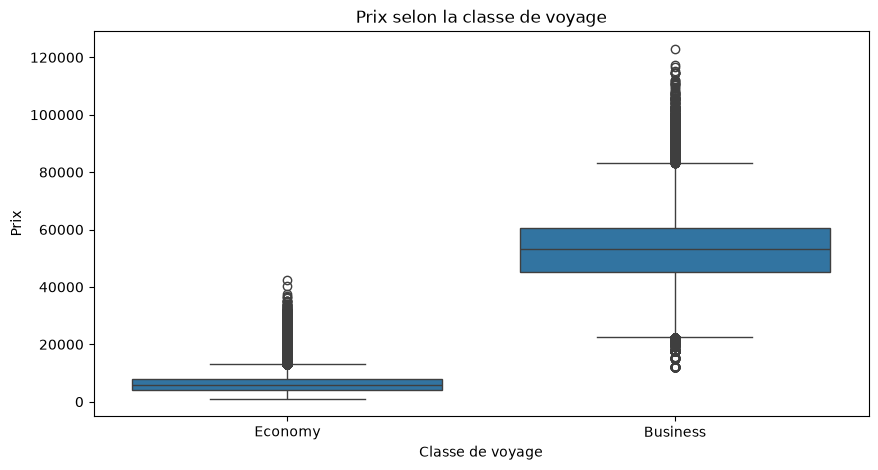

In [19]:
#class vs price
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x='class',
    y='price'
)
plt.title("Prix selon la classe de voyage")
plt.xlabel("Classe de voyage")
plt.ylabel("Prix")
plt.show()

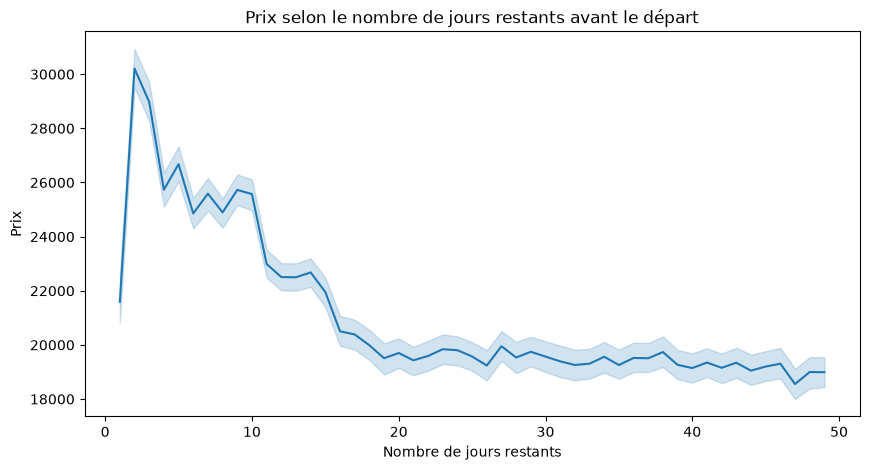

In [21]:
# days_left vs price
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df,
    x='days_left',
    y='price'
)
plt.title("Prix selon le nombre de jours restants avant le départ")
plt.xlabel("Nombre de jours restants")
plt.ylabel("Prix")
plt.show()

In [ ]:
# preprocessing part 
#Missing Value 
df.isnull().sum()

Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [ ]:
target = 'price'

X = df.drop(columns=['price', 'Unnamed: 0'])
y = df['price']
print(X.columns)
print(y)

In [ ]:
#install scikit-learn 
from sklearn.model_selection import train_test_split

In [34]:
#divise data 80% train/20% test 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
)

In [ ]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

In [ ]:
#use SimpleImputer and StandardScaler
numerical_columns = [
    'duration',
    'days_left'
]

In [ ]:
#OrdinalEncoder
ordinal_columns = [
    'stops',
    'class'
]

In [ ]:
#OneHotEncoder
categorical_columns = [
    'airline',
    'flight',
    'source_city',
    'destination_city',
    'departure_time',
    'arrival_time'
]

In [22]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [23]:
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [24]:
ordinal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

In [25]:
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [26]:
from sklearn.compose import ColumnTransformer

In [27]:
preprocessor = ColumnTransformer([
    ('num', numerical_transformer, numerical_columns),
    ('ord', ordinal_transformer, ordinal_columns),
    ('cat', categorical_transformer, categorical_columns)
])

In [28]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [ ]:
print(X_train_processed.shape)
print(X_test_processed.shape)

In [82]:
#reference Model 
from sklearn.dummy import DummyRegressor
model = DummyRegressor(strategy='mean')

In [83]:
# Le preprocessing est intégré dans un Pipeline Scikit-learn.
model_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', model)
])

In [ ]:
#fit 
model_pipeline.fit(X_train, y_train)

In [ ]:
#prédiction 
y_pred = model_pipeline.predict(X_test)

print(y_pred)

In [86]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [ ]:
#Regrission Metrics pour DummyRegressor res
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² :", r2)
print("MAE :", mae)
print("RMSE :", rmse)

In [88]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [89]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return mae, rmse, r2

In [92]:
models = {
    "LinearRegression": LinearRegression(),

    "Ridge_0.1": Ridge(alpha=0.1),
    "Ridge_1": Ridge(alpha=1),
    "Ridge_10": Ridge(alpha=10),
    "Ridge_100": Ridge(alpha=100),

    "RandomForest": RandomForestRegressor(
        n_estimators=10,
        random_state=42
    )
}

In [94]:
results = []

for name, model in models.items():

    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)

    mae, rmse, r2 = evaluate_model(
        pipeline,
        X_test,
        y_test
    )

    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })

In [95]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R²
0,LinearRegression,4316.593906,6315.409291,0.922510
1,Ridge_0.1,4317.205694,6316.395131,0.922486
2,Ridge_1,4316.344896,6316.883627,0.922474
3,Ridge_10,4317.023122,6323.480414,0.922312
4,Ridge_100,4339.738597,6369.200725,0.921184
5,RandomForest,886.018973,2464.261230,0.988202
